In [ ]:
import cv2
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt

In [ ]:
IMAGE_PATH = Path("C:/Recognition_of_linear_water_bodies/1_stage/images/2023_Alyoshnya_M2000-3-3-25.jpeg")  # 👈 Изображение БЕЗ заливки, но С обводкой
JSON_PATH = Path("C:/Recognition_of_linear_water_bodies/1_stage/annotations/2023_Alyoshnya_M2000-3-3-25.json")  # 👈 Оригинальный JSON

CONTOUR_THICKNESS = 3  # подобранная толщина

print(f"Изображение: {IMAGE_PATH}")
print(f"JSON: {JSON_PATH}")

image = cv2.imread(str(IMAGE_PATH))
if image is None:
    print(f"Не удалось загрузить {IMAGE_PATH}")
else:
    print(f"Изображение загружено: {image.shape}")

with open(JSON_PATH, 'r') as f:
    annotation = json.load(f)

polygons = annotation.get('polygons', [])
print(f"Полигонов: {len(polygons)}")

Изображение: C:\Recognition_of_linear_water_bodies\1_stage\images\2023_Alyoshnya_M2000-3-3-25.jpeg
JSON: C:\Recognition_of_linear_water_bodies\1_stage\annotations\2023_Alyoshnya_M2000-3-3-25.json
✅ Изображение загружено: (1250, 1250, 3)
✅ Полигонов: 0


Создание маски контура с подобранной толщиной

📊 Маска обводки: 0 пикселей
📁 Результаты будут сохранены в: c:\Users\Ева\Desktop\рб 2025\Датасеты\Очистка датасетов от отрисовки\contour_removal_test


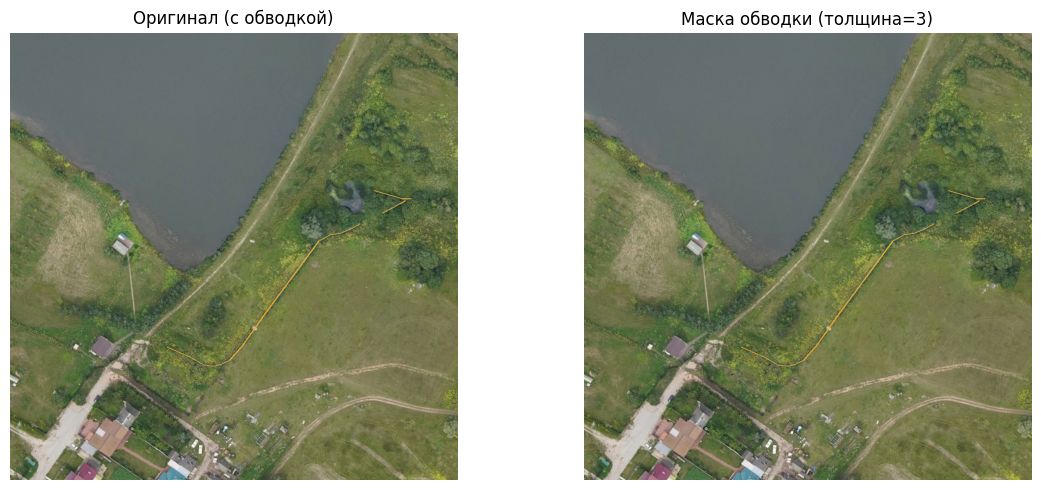

✅ Маска создана


In [ ]:
def create_contour_mask(image_shape, polygons, thickness=CONTOUR_THICKNESS):
    """Создает маску только для контура"""
    h, w = image_shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    
    for polygon in polygons:
        pts = np.array(polygon, dtype=np.int32)
        cv2.polylines(mask, [pts], isClosed=True, color=255, thickness=thickness)
    
    return mask

OUTPUT_METHOD_DIR = Path("./contour_removal_test")
OUTPUT_METHOD_DIR.mkdir(exist_ok=True)

contour_mask = create_contour_mask(image.shape, polygons)

print(f"Маска обводки: {np.sum(contour_mask > 0)} пикселей")
print(f"Результаты будут сохранены в: {OUTPUT_METHOD_DIR.absolute()}")

cv2.imwrite(str(OUTPUT_METHOD_DIR / "original.jpg"), image)
cv2.imwrite(str(OUTPUT_METHOD_DIR / "contour_mask.jpg"), contour_mask)

overlay = image.copy()
overlay[contour_mask > 0] = [0, 0, 255]  # Красный

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Оригинал (с обводкой)")
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Маска обводки (толщина={CONTOUR_THICKNESS})")
axes[1].axis('off')
plt.tight_layout()
plt.show()

print("Маска создана")

Подбор метода

In [ ]:
import cv2
import numpy as np
from pathlib import Path

TELEA_OUTPUT_DIR = Path("./telea_test")
TELEA_OUTPUT_DIR.mkdir(exist_ok=True)


results = {}

# Параметры для тестирования:
# (радиус, использовать_расширение_маски, радиус_расширения)

params = [
    # Радиус 1 - минимальный
    (1, False, 0, "r1_no_dilate"),
    (2, False, 0, "r2_no_dilate"),
    (3, False, 0, "r3_no_dilate"),
    (5, False, 0, "r5_no_dilate"),
    
    # Радиус 1 с разным расширением
    (1, True, 1, "r1_dilate1"),
    (1, True, 2, "r1_dilate2"),
    (2, True, 1, "r2_dilate1"),
    (3, True, 1, "r3_dilate1"),
]

for radius, use_dilate, dilate_size, name in params:
    mask = contour_mask.copy()
    
    if use_dilate:
        kernel = np.ones((dilate_size*2+1, dilate_size*2+1), np.uint8)
        mask = cv2.dilate(mask, kernel, iterations=1)
    
    result = cv2.inpaint(image, mask, inpaintRadius=radius, flags=cv2.INPAINT_TELEA)
    results[name] = result
    
    cv2.imwrite(str(TELEA_OUTPUT_DIR / f"{name}.jpg"), result)
    cv2.imwrite(str(TELEA_OUTPUT_DIR / f"{name}.png"), result)
    print(f"✅ {name}: radius={radius}, dilate={dilate_size if use_dilate else 'no'}")

cv2.imwrite(str(TELEA_OUTPUT_DIR / "original.jpg"), image)
cv2.imwrite(str(TELEA_OUTPUT_DIR / "mask.jpg"), contour_mask)

print(f"\nВсе результаты в: {TELEA_OUTPUT_DIR.absolute()}")

🔄 Тестирование Telea с разными параметрами...

✅ r1_no_dilate: radius=1, dilate=no
✅ r2_no_dilate: radius=2, dilate=no
✅ r3_no_dilate: radius=3, dilate=no
✅ r5_no_dilate: radius=5, dilate=no
✅ r1_dilate1: radius=1, dilate=1
✅ r1_dilate2: radius=1, dilate=2
✅ r2_dilate1: radius=2, dilate=1
✅ r3_dilate1: radius=3, dilate=1

📁 Все результаты в: c:\Users\Ева\Desktop\рб 2025\Датасеты\Очистка датасетов от отрисовки\telea_test


In [ ]:
for name, result in results.items():
    jpg_path = OUTPUT_METHOD_DIR / f"{name}.jpg"
    cv2.imwrite(str(jpg_path), result)
    
    png_path = OUTPUT_METHOD_DIR / f"{name}.png"
    cv2.imwrite(str(png_path), result)
    
    print(f"{name}.jpg / .png")

print(f"\nВсе результаты сохранены в: {OUTPUT_METHOD_DIR.absolute()}")

💾 Сохранение результатов...

✅ Telea_r2.jpg / .png
✅ Telea_r3.jpg / .png
✅ Telea_r5.jpg / .png
✅ NS_r2.jpg / .png
✅ NS_r3.jpg / .png
✅ NS_r5.jpg / .png
✅ Telea_dilated1.jpg / .png
✅ Telea_dilated2.jpg / .png
✅ Median3_Telea.jpg / .png
✅ Median5_Telea.jpg / .png

📁 Все результаты сохранены в: c:\Users\Ева\Desktop\рб 2025\Датасеты\Очистка датасетов от отрисовки\contour_removal_test
